2. MACHINE LEARNING FOR REGRESSION

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


2.2 DATA PREPARATION

In [ ]:
# data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [ ]:
# !wget $data 

--2026-10-03 09:47:17--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... 

connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.1s    

2026-10-03 09:47:18 (13.7 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [4]:
df = pd.read_csv('data.csv')
len(df)

11914

In [5]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
df.columns.str.lower()

Index(['make', 'model', 'year', 'engine fuel type', 'engine hp',
       'engine cylinders', 'transmission type', 'driven_wheels',
       'number of doors', 'market category', 'vehicle size', 'vehicle style',
       'highway mpg', 'city mpg', 'popularity', 'msrp'],
      dtype='str')

In [7]:
df.columns.str.lower().str.replace(' ', '_')

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [10]:
df.dtypes[df.dtypes == 'str']

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [11]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [12]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [13]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


2.3: EXPLORATORY DATA ANALYSIS


In [14]:

for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

<Axes: xlabel='msrp', ylabel='Count'>

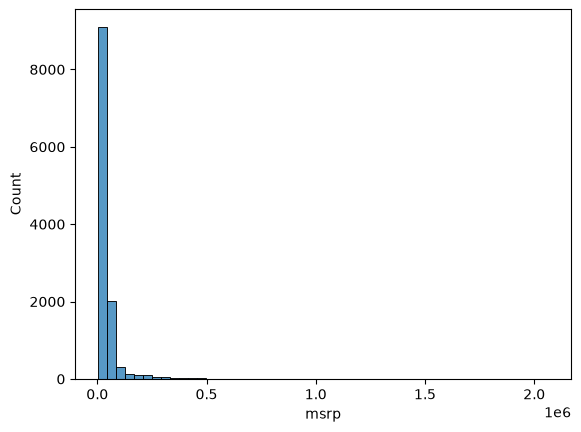

In [15]:
# distribution of prices
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

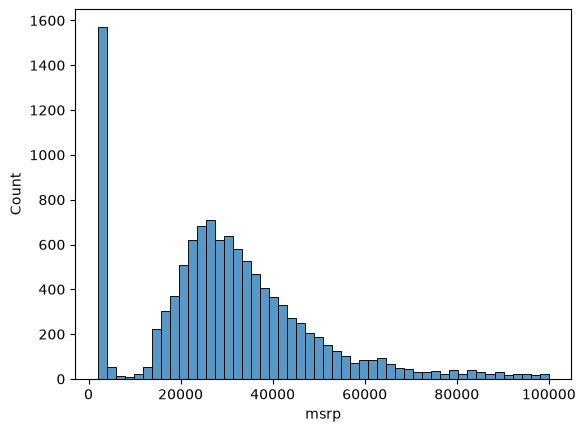

In [16]:
# prices below 100000
sns.histplot(df.msrp[df.msrp<100000],bins=50)

In [17]:
np.log([0+1,1+1,10+1,1000+1,100000+1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [18]:
np.log1p([0,1,10,1000,100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [19]:
price_logs=np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

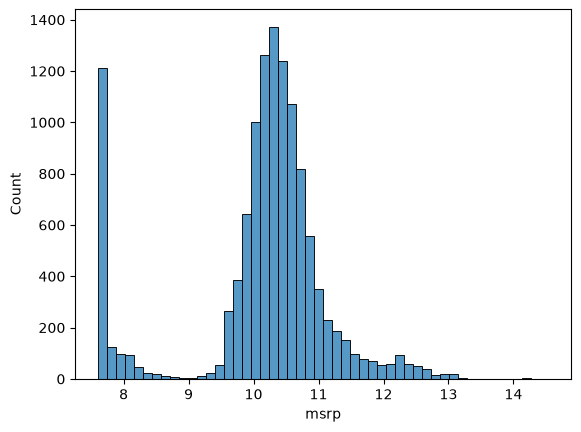

In [20]:
# normal distribution
sns.histplot(price_logs,bins=50)

In [21]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

2.4 SETTING UP THE VALIDATION FRAMEWORK

In [22]:

n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train= n- n_val-n_test

In [41]:
n_val,n_test,n_train

(2382, 2382, 7150)

In [42]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [43]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val+n_test]
df_train = df.iloc[n_val+n_test:]

In [44]:
idx = np.arange(n)
np.random.shuffle(idx)

In [45]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [52]:
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

In [47]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [48]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [49]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [53]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,mercedes-benz,c-class,2015,premium_unleaded_(required),201.0,4.0,automatic,rear_wheel_drive,2.0,luxury,compact,coupe,31,22,617,39400
1,kia,rondo,2009,regular_unleaded,175.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,wagon,27,20,1720,17495
2,volkswagen,cc,2015,premium_unleaded_(recommended),200.0,4.0,automated_manual,front_wheel_drive,4.0,performance,midsize,sedan,31,22,873,34095
3,bmw,5_series_gran_turismo,2015,premium_unleaded_(required),445.0,8.0,automatic,all_wheel_drive,4.0,"hatchback,luxury,performance",large,4dr_hatchback,24,16,3916,71400
4,chevrolet,impala_limited,2015,flex-fuel_(unleaded/e85),300.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,large,sedan,30,18,1385,26840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,volkswagen,golf_gti,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,4.0,"hatchback,performance",compact,4dr_hatchback,33,25,873,29485
7146,nissan,gt-r,2015,premium_unleaded_(recommended),545.0,6.0,automated_manual,all_wheel_drive,2.0,high-performance,midsize,coupe,23,16,2009,115710
7147,audi,q7,2015,diesel,240.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury,diesel",large,4dr_suv,28,19,3105,59900
7148,volkswagen,jetta,2015,regular_unleaded,170.0,4.0,manual,front_wheel_drive,4.0,NaN,midsize,sedan,37,25,873,20895


In [33]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [34]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,mazda,b-series_truck,2008,regular_unleaded,143.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,regular_cab_pickup,26,21,586
1,lamborghini,gallardo,2014,premium_unleaded_(required),570.0,10.0,manual,all_wheel_drive,2.0,"exotic,factory_tuner,high-performance",compact,convertible,20,13,1158
2,chrysler,crossfire,2007,premium_unleaded_(required),215.0,6.0,manual,rear_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,23,15,1013
3,saab,9-3_griffin,2012,premium_unleaded_(recommended),220.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,18,376
4,honda,civic,2017,regular_unleaded,174.0,4.0,manual,front_wheel_drive,2.0,performance,compact,coupe,41,30,2202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,gmc,sierra_1500,2016,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,23,16,549
7146,dodge,monaco,1992,regular_unleaded,150.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,24,16,1851
7147,suzuki,esteem,2001,regular_unleaded,122.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,32,24,481
7148,mazda,cx-5,2014,regular_unleaded,184.0,4.0,automatic,all_wheel_drive,4.0,crossover,midsize,4dr_suv,30,24,586


2.5 LINEAR REGRESSION SIMPLE

In [35]:
df_train.iloc[10]

make                                     land_rover
model                            range_rover_evoque
year                                           2015
engine_fuel_type     premium_unleaded_(recommended)
engine_hp                                     240.0
engine_cylinders                                4.0
transmission_type                         automatic
driven_wheels                       all_wheel_drive
number_of_doors                                 4.0
market_category                    crossover,luxury
vehicle_size                                compact
vehicle_style                               4dr_suv
highway_mpg                                      30
city_mpg                                         21
popularity                                      258
Name: 10, dtype: object

In [64]:
xi=[453,11,86]

In [65]:
w0=7.17
w=[0.01,0.04,0.002]

In [66]:
def linear_regression(xi):
    n=len(xi)
    pred=w0
    for j in range (n):
        pred= pred + w[j] * xi[j]
    return pred

In [67]:
linear_regression(xi)

12.312

In [ ]:
# the price of the  car is about $222347
np.expm1(12.312).item()

222347.2221101062

In [70]:
np.log1p(222347.2221101062)

np.float64(12.312)

2.6:LINEAR REGRESSION VECTOR FORM

In [81]:
def dot(xi,w):
    n= len(xi)

    res=0.0

    for j in range (n):
        res= res +  xi[j] *w[j] 

    return res




In [82]:
def linear_regression (xi):
    return w0 + dot(xi, w)

In [83]:
w_new = [w0] + w

In [84]:
def linear_regression (xi):
    xi=[1] + xi
    return dot(xi,w_new)

In [85]:
linear_regression(xi)

12.312

Linear regression for all cars

In [87]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]
x= [x1,x2,x10]
x=np.array(x)
x

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [88]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [90]:
def linear_regression(xi):
    return x.dot(w_new)

In [91]:
linear_regression(x)

array([12.38 , 13.552, 12.312])

2.7 TRAINING A LINEAR REGRESSION MODEL